In [2]:
import os
os.environ['PYSPARK_SUBMIT_ARGS'] = '--packages io.delta:delta-spark_2.12:3.2.0 pyspark-shell'

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MovieLens") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .config("spark.driver.memory", "2g") \
    .master("local[2]") \
    .getOrCreate()

print("Spark hazır:", spark.version)

Spark hazır: 3.5.0


In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MovieLens") \
    .getOrCreate()

print("Spark çalışıyor:", spark.version)

Spark çalışıyor: 3.5.0


In [2]:
ratings = spark.read.csv("/home/jovyan/data/ml-25m/ml-25m/ratings.csv", 
                         header=True, 
                         inferSchema=True)

ratings.printSchema()
ratings.show(5)

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nullable = true)

+------+-------+------+----------+
|userId|movieId|rating| timestamp|
+------+-------+------+----------+
|     1|    296|   5.0|1147880044|
|     1|    306|   3.5|1147868817|
|     1|    307|   5.0|1147868828|
|     1|    665|   5.0|1147878820|
|     1|    899|   3.5|1147868510|
+------+-------+------+----------+
only showing top 5 rows



In [3]:
movies = spark.read.csv("/home/jovyan/data/ml-25m/ml-25m/movies.csv",
                        header=True,
                        inferSchema=True)

movies.printSchema()
movies.show(5)

root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)

+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
+-------+--------------------+--------------------+
only showing top 5 rows



In [4]:
print("Rating sayısı:", ratings.count())
print("Film sayısı:", movies.count())

Rating sayısı: 25000095
Film sayısı: 62423


In [5]:
spark.sparkContext._jvm.System.setProperty("io.delta.sql.DeltaSparkSessionExtension", "")

spark.stop()

spark = SparkSession.builder \
    .appName("MovieLens") \
    .config("spark.jars.packages", "io.delta:delta-spark_2.12:3.2.0") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .getOrCreate()

print("Delta Lake hazır:", spark.version)

Delta Lake hazır: 3.5.0


In [6]:
ratings = spark.read.csv("/home/jovyan/data/ml-25m/ml-25m/ratings.csv", 
                         header=True, 
                         inferSchema=True)

ratings.write \
    .format("delta") \
    .mode("overwrite") \
    .save("/home/jovyan/data/delta/bronze/ratings")

print("Bronze tablo yazıldı!")

Py4JJavaError: An error occurred while calling o72.csv.
: org.apache.spark.SparkException: Cannot find catalog plugin class for catalog 'spark_catalog': org.apache.spark.sql.delta.catalog.DeltaCatalog.
	at org.apache.spark.sql.errors.QueryExecutionErrors$.catalogPluginClassNotFoundForCatalogError(QueryExecutionErrors.scala:1925)
	at org.apache.spark.sql.connector.catalog.Catalogs$.load(Catalogs.scala:70)
	at org.apache.spark.sql.connector.catalog.CatalogManager.loadV2SessionCatalog(CatalogManager.scala:67)
	at org.apache.spark.sql.connector.catalog.CatalogManager.$anonfun$v2SessionCatalog$2(CatalogManager.scala:86)
	at scala.collection.mutable.HashMap.getOrElseUpdate(HashMap.scala:86)
	at org.apache.spark.sql.connector.catalog.CatalogManager.$anonfun$v2SessionCatalog$1(CatalogManager.scala:86)
	at scala.Option.map(Option.scala:230)
	at org.apache.spark.sql.connector.catalog.CatalogManager.v2SessionCatalog(CatalogManager.scala:85)
	at org.apache.spark.sql.connector.catalog.CatalogManage

In [7]:
spark.stop()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MovieLens") \
    .config("spark.jars.packages", "io.delta:delta-spark_2.12:3.2.0") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .master("local[*]") \
    .getOrCreate()

print("Spark hazır:", spark.version)

Spark hazır: 3.5.0


In [1]:
import os
os.environ['PYSPARK_SUBMIT_ARGS'] = '--packages io.delta:delta-spark_2.12:3.2.0 pyspark-shell'

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MovieLens") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .master("local[*]") \
    .getOrCreate()

print("Spark hazır:", spark.version)

Spark hazır: 3.5.0


In [2]:
spark.stop()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MovieLens") \
    .config("spark.jars.packages", "io.delta:delta-spark_2.12:3.2.0") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .master("local[*]") \
    .getOrCreate()

print("Spark hazır:", spark.version)

Spark hazır: 3.5.0


In [4]:
ratings = spark.read.csv("/home/jovyan/data/ml-25m/ml-25m/ratings.csv", 
                         header=True, 
                         inferSchema=True)

ratings.write \
    .format("delta") \
    .mode("overwrite") \
    .save("/home/jovyan/data/delta/bronze/ratings")

print("Bronze tablo yazıldı!")

Bronze tablo yazıldı!


In [5]:
from pyspark.sql.functions import col, from_unixtime

# ratings ve movies'i oku
ratings = spark.read.format("delta").load("/home/jovyan/data/delta/bronze/ratings")
movies = spark.read.csv("/home/jovyan/data/ml-25m/ml-25m/movies.csv", header=True, inferSchema=True)

# Temizle ve birleştir
silver = ratings \
    .dropna() \
    .dropDuplicates() \
    .join(movies, on="movieId", how="left") \
    .withColumn("rating_date", from_unixtime(col("timestamp")).cast("timestamp"))

# Silver'a yaz
silver.write \
    .format("delta") \
    .mode("overwrite") \
    .save("/home/jovyan/data/delta/silver/ratings")

print("Silver tablo yazıldı!")
silver.show(5)

ERROR:root:Exception while sending command.
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3526, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_1892/2573593841.py", line 18, in <module>
    .save("/home/jovyan/data/delta/silver/ratings")
     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/spark/python/pyspark/sql/readwriter.py", line 1463, in save
    self._jwrite.save(path)
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/java_gateway.py", line 1322, in __call__
    return_value = get_return_value(
                   ^^^^^^^^^^^^^^^^^
  File "/usr/local/spark/python/pyspark/errors/exceptions/captured.py", line 179, in deco
    return f(*a, **kw)
           ^^^^^^^^^^^
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/protocol.py", line 326, in get_return_value
    raise Py4JJavaError(
py4j.protocol.Py4JJavaError: <exception

ConnectionRefusedError: [Errno 111] Connection refused

In [1]:
import os
os.environ['PYSPARK_SUBMIT_ARGS'] = '--packages io.delta:delta-spark_2.12:3.2.0 pyspark-shell'

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MovieLens") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .config("spark.driver.memory", "2g") \
    .master("local[2]") \
    .getOrCreate()

print("Spark hazır:", spark.version)

Spark hazır: 3.5.0


In [2]:
from pyspark.sql.functions import col, from_unixtime

ratings = spark.read.csv("/home/jovyan/data/ml-25m/ml-25m/ratings.csv", 
                         header=True, inferSchema=True).limit(1000000)

movies = spark.read.csv("/home/jovyan/data/ml-25m/ml-25m/movies.csv", 
                        header=True, inferSchema=True)

silver = ratings \
    .dropna() \
    .dropDuplicates() \
    .join(movies, on="movieId", how="left") \
    .withColumn("rating_date", from_unixtime(col("timestamp")).cast("timestamp"))

silver.write \
    .format("delta") \
    .mode("overwrite") \
    .save("/home/jovyan/data/delta/silver/ratings")

print("Silver tablo yazıldı!")
silver.show(5)

Silver tablo yazıldı!
+-------+------+------+----------+--------------------+--------------------+-------------------+
|movieId|userId|rating| timestamp|               title|              genres|        rating_date|
+-------+------+------+----------+--------------------+--------------------+-------------------+
|    296|     1|   5.0|1147880044| Pulp Fiction (1994)|Comedy|Crime|Dram...|2006-05-17 15:34:04|
|    306|     1|   3.5|1147868817|Three Colors: Red...|               Drama|2006-05-17 12:26:57|
|    307|     1|   5.0|1147868828|Three Colors: Blu...|               Drama|2006-05-17 12:27:08|
|    665|     1|   5.0|1147878820|  Underground (1995)|    Comedy|Drama|War|2006-05-17 15:13:40|
|    899|     1|   3.5|1147868510|Singin' in the Ra...|Comedy|Musical|Ro...|2006-05-17 12:21:50|
+-------+------+------+----------+--------------------+--------------------+-------------------+
only showing top 5 rows



In [5]:
from pyspark.sql.functions import avg, count, year, hour

# Film bazlı istatistikler
movie_stats = silver.groupBy("movieId").agg(
    avg("rating").alias("movie_avg_rating"),
    count("rating").alias("movie_rating_count")
)

# Kullanıcı bazlı istatistikler
user_stats = silver.groupBy("userId").agg(
    avg("rating").alias("user_avg_rating"),
    count("rating").alias("user_rating_count")
)

# Hepsini birleştir
gold = silver \
    .join(movie_stats, on="movieId", how="left") \
    .join(user_stats, on="userId", how="left") \
    .withColumn("rating_year", year(col("rating_date"))) \
    .withColumn("rating_hour", hour(col("rating_date")))

gold.write \
    .format("delta") \
    .mode("overwrite") \
    .save("/home/jovyan/data/delta/gold/features")

print("Gold tablo yazıldı!")
gold.show(3)

NameError: name 'silver' is not defined

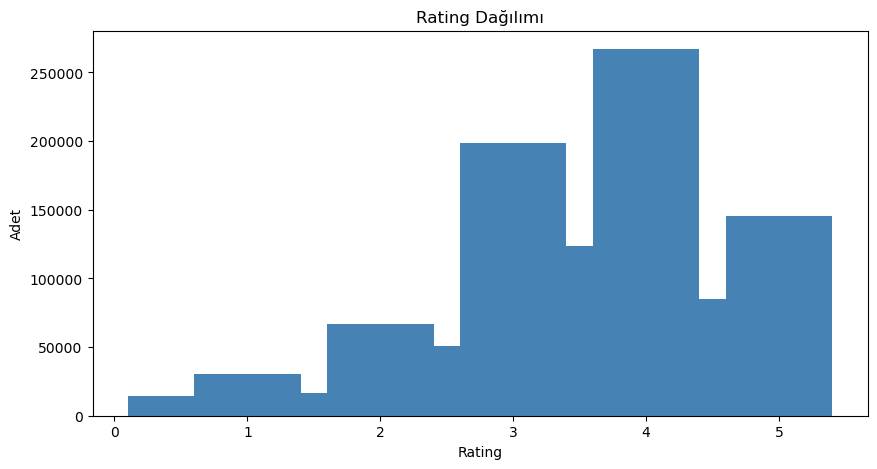

In [4]:
import matplotlib.pyplot as plt

# Rating dağılımı
rating_dist = silver.groupBy("rating").count().orderBy("rating").toPandas()

plt.figure(figsize=(10,5))
plt.bar(rating_dist["rating"], rating_dist["count"], color="steelblue")
plt.title("Rating Dağılımı")
plt.xlabel("Rating")
plt.ylabel("Adet")
plt.show()

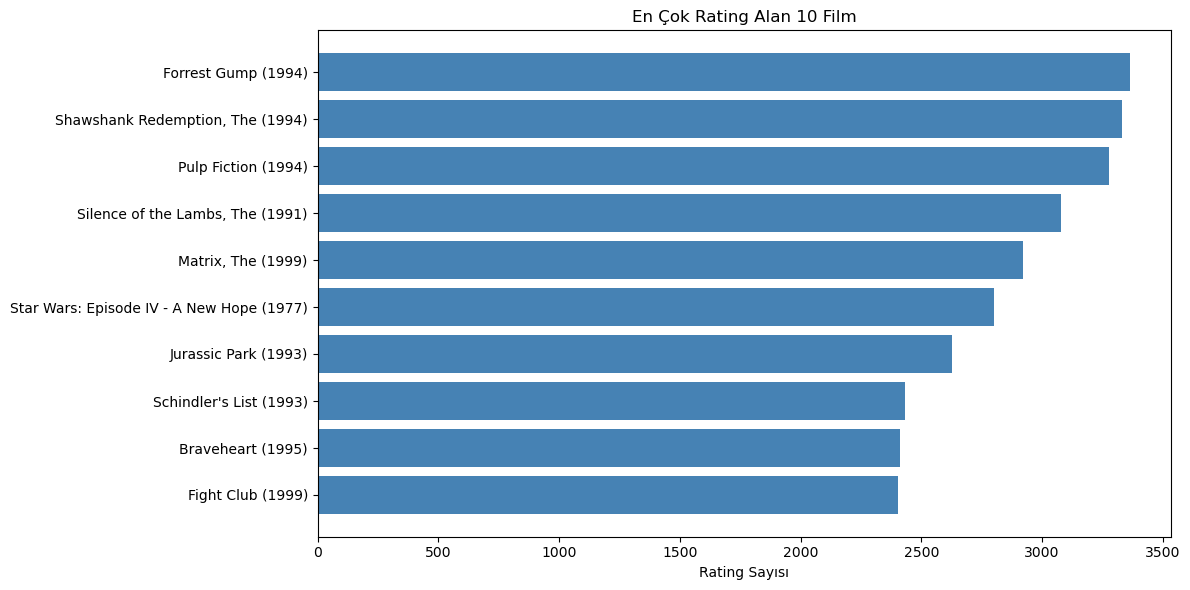

In [5]:
top_movies = silver.groupBy("title").count() \
    .orderBy("count", ascending=False) \
    .limit(10) \
    .toPandas()

plt.figure(figsize=(12,6))
plt.barh(top_movies["title"], top_movies["count"], color="steelblue")
plt.title("En Çok Rating Alan 10 Film")
plt.xlabel("Rating Sayısı")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

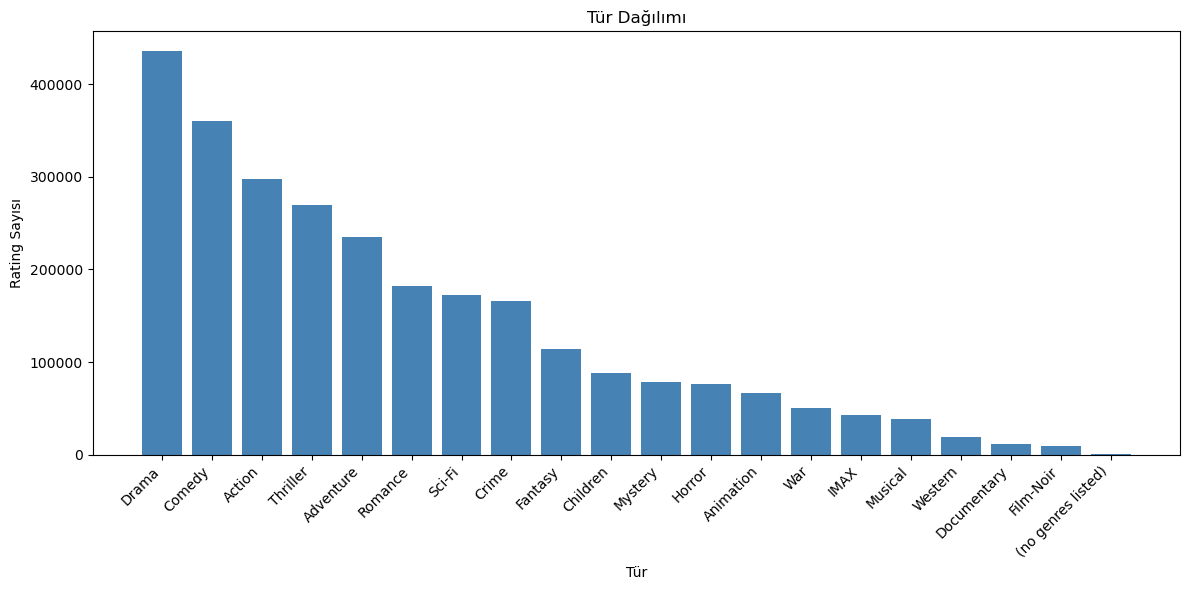

In [6]:
from pyspark.sql.functions import explode, split

genre_dist = silver \
    .select(explode(split(col("genres"), "\\|")).alias("genre")) \
    .groupBy("genre").count() \
    .orderBy("count", ascending=False) \
    .toPandas()

plt.figure(figsize=(12,6))
plt.bar(genre_dist["genre"], genre_dist["count"], color="steelblue")
plt.title("Tür Dağılımı")
plt.xlabel("Tür")
plt.ylabel("Rating Sayısı")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

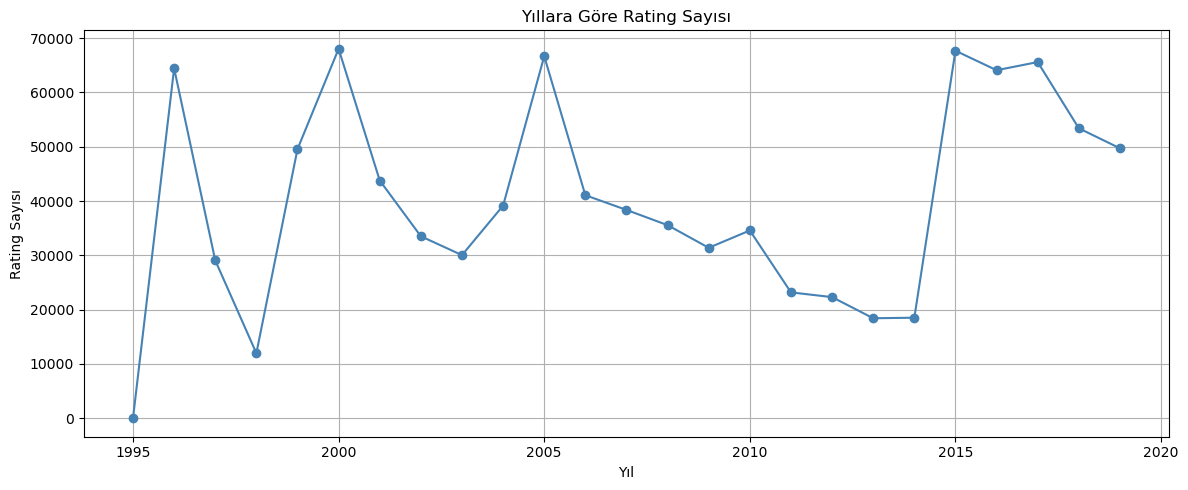

In [7]:
yearly = gold.groupBy("rating_year").count() \
    .orderBy("rating_year") \
    .toPandas()

plt.figure(figsize=(12,5))
plt.plot(yearly["rating_year"], yearly["count"], marker="o", color="steelblue")
plt.title("Yıllara Göre Rating Sayısı")
plt.xlabel("Yıl")
plt.ylabel("Rating Sayısı")
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, DecisionTreeRegressor, RandomForestRegressor, GBTRegressor, GeneralizedLinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
import mlflow
import mlflow.spark

# Özellikleri seç
feature_cols = ["movie_avg_rating", "movie_rating_count", "user_avg_rating", "user_rating_count", "rating_year", "rating_hour"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
data = assembler.transform(gold.dropna()).select("features", "rating")

# Train/Test split
train, test = data.randomSplit([0.8, 0.2], seed=42)

print("Train:", train.count(), "Test:", test.count())

ImportError: cannot import name 'Sentinel' from 'typing_extensions' (/opt/conda/lib/python3.11/site-packages/typing_extensions.py)

In [1]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, DecisionTreeRegressor, RandomForestRegressor, GBTRegressor, GeneralizedLinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
import mlflow
import mlflow.spark

# Özellikleri seç
feature_cols = ["movie_avg_rating", "movie_rating_count", "user_avg_rating", "user_rating_count", "rating_year", "rating_hour"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
data = assembler.transform(gold.dropna()).select("features", "rating")

# Train/Test split
train, test = data.randomSplit([0.8, 0.2], seed=42)

print("Train:", train.count(), "Test:", test.count())

AssertionError: 